In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler

# Загрузка
df = pd.read_csv("texas.csv")

# Фильтруем Техас (treated) и доноров
treated_fip = 48
treated = df[df["statefip"] == treated_fip].copy()
donors = df[(df["statefip"] != treated_fip) & (df["statefip"] >= 1)].copy()

# Периоды
pre_years = list(range(1985, 1993))   # 1985-1992
post_years = list(range(1993, 2001))  # 1993-2000

print("Донорных штатов:", donors["statefip"].nunique())
print("Предпериод:", pre_years)
print("Постпериод:", post_years)

Донорных штатов: 50
Предпериод: [1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992]
Постпериод: [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000]


In [3]:
predictors = ["poverty", "income", "alcohol", "aidscapita", "black", "perc1519"]

# Средние за pre-period для каждого штата
X_pre = donors[donors["year"].isin(pre_years)].groupby("statefip")[predictors].mean()
X_treated_pre = treated[treated["year"].isin(pre_years)][predictors].mean().values

# Матрица предикторов доноров (строки — штаты, столбцы — предикторы)
X_donors = X_pre.values  # shape: (n_donors, n_predictors)
donor_fips = X_pre.index.values

In [5]:
def loss(w, X_donors, X_treated):
    """Взвешенная сумма квадратов отклонений"""
    synthetic = np.dot(w, X_donors)
    return np.sum((X_treated - synthetic) ** 2)

def constraint(w):
    return np.sum(w) - 1.0  # сумма весов = 1

n_donors = X_donors.shape[0]
bounds = [(0, 1)] * n_donors
constraints = [{"type": "eq", "fun": constraint}]
w0 = np.ones(n_donors) / n_donors  # равные начальные веса

result = minimize(
    loss, w0, args=(X_donors, X_treated_pre),
    bounds=bounds, constraints=constraints,
    method="SLSQP"
)

weights = result.x
print("Оптимизация завершена. Успех:", result.success)
print("Сумма весов:", np.sum(weights))

Оптимизация завершена. Успех: True
Сумма весов: 1.0


In [7]:
weight_df = pd.DataFrame({
    "statefip": donor_fips,
    "weight": weights
}).sort_values("weight", ascending=False)

print("\n=== Веса донорных штатов (топ-10) ===")
print(weight_df[weight_df["weight"] > 0.001].head(10))


=== Веса донорных штатов (топ-10) ===
    statefip  weight
0        1.0    0.02
37      41.0    0.02
27      31.0    0.02
28      32.0    0.02
29      33.0    0.02
30      34.0    0.02
31      35.0    0.02
32      36.0    0.02
33      37.0    0.02
34      38.0    0.02


In [9]:
# Матрица bmprison по годам для доноров
bmprison_donors = donors.pivot(index="statefip", columns="year", values="bmprison")
bmprison_donors = bmprison_donors.reindex(columns=sorted(df["year"].unique()))

# Синтетический Техас
synthetic_bmprison = np.dot(weights, bmprison_donors.values)

# Фактический Техас
actual_bmprison = treated.set_index("year").reindex(bmprison_donors.columns)["bmprison"].values

years_all = bmprison_donors.columns.values

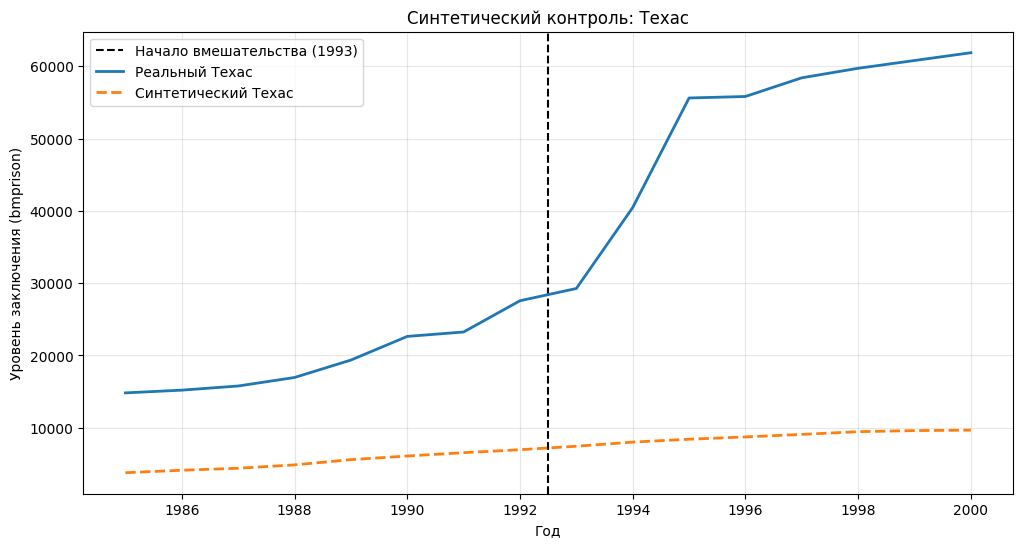

In [11]:
plt.figure(figsize=(12, 6))
plt.axvline(x=1992.5, color="black", linestyle="--", label="Начало вмешательства (1993)")
plt.plot(years_all, actual_bmprison, label="Реальный Техас", linewidth=2)
plt.plot(years_all, synthetic_bmprison, label="Синтетический Техас", linestyle="--", linewidth=2)
plt.xlabel("Год")
plt.ylabel("Уровень заключения (bmprison)")
plt.title("Синтетический контроль: Техас")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
synthetic_pre = np.dot(weights, X_donors)

balance = pd.DataFrame({
    "Предиктор": predictors,
    "Реальный Техас": X_treated_pre,
    "Синтетический Техас": synthetic_pre,
    "Абс. ошибка": np.abs(X_treated_pre - synthetic_pre)
})
print("\n=== Баланс предикторов (1985–1992) ===")
print(balance.round(4))


=== Баланс предикторов (1985–1992) ===
    Предиктор  Реальный Техас  Синтетический Техас  Абс. ошибка
0     poverty         17.2000              13.3922       3.8078
1      income      16108.6250           17080.3450     971.7200
2     alcohol          2.5112               2.5169       0.0056
3  aidscapita         10.0475               6.6203       3.4272
4       black         16.0201              11.4124       4.6077
5    perc1519          7.8796               7.4665       0.4131


In [19]:
pre_mask = np.isin(years_all, pre_years)  # ✅ правильный способ для numpy array
mspe_pre = np.mean((actual_bmprison[pre_mask] - synthetic_bmprison[pre_mask]) ** 2)
print(f"\nMSPE в донорный период (1985-1992): {mspe_pre:.4f}")

# Дополнительно: MSPE в пост-период (для справки)
post_mask = np.isin(years_all, post_years)
mspe_post = np.mean((actual_bmprison[post_mask] - synthetic_bmprison[post_mask]) ** 2)
print(f"MSPE в пост-период (1993-2000): {mspe_post:.4f}")

# Отношение пост/до (чем больше, тем сильнее эффект)
ratio = mspe_post / mspe_pre
print(f"Отношение MSPE (post/pre): {ratio:.2f}")


MSPE в донорный период (1985-1992): 210696118.1952
MSPE в пост-период (1993-2000): 2033298068.2659
Отношение MSPE (post/pre): 9.65
